# Using pre-trained AI models

## Using image segmentation models

As seen in the first lab, we can use existing models to help us segment images. Let's use it to segment porc belly images.

In [4]:
import cv2

data_path="data"
rgb_img_path=f"{data_path}/1A_rgb.png"
rgb_img=cv2.imread(rgb_img_path)

In [7]:
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import supervision as sv

def detect_with_sam(rgb_img):
    DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"DEVICE = {DEVICE}")

    MODEL_TYPE = "vit_l"
    SAM_SAM_CHECKPOINT_PATH = data_path + "/sam_vit_l_0b3195.pth"

    sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_SAM_CHECKPOINT_PATH).to(device=DEVICE)
    mask_generator = SamAutomaticMaskGenerator(sam)
    sam_result = mask_generator.generate(rgb_img)
    return sv.Detections.from_sam(sam_result=sam_result)

sam_detections = detect_with_sam(rgb_img)

DEVICE = cuda:0


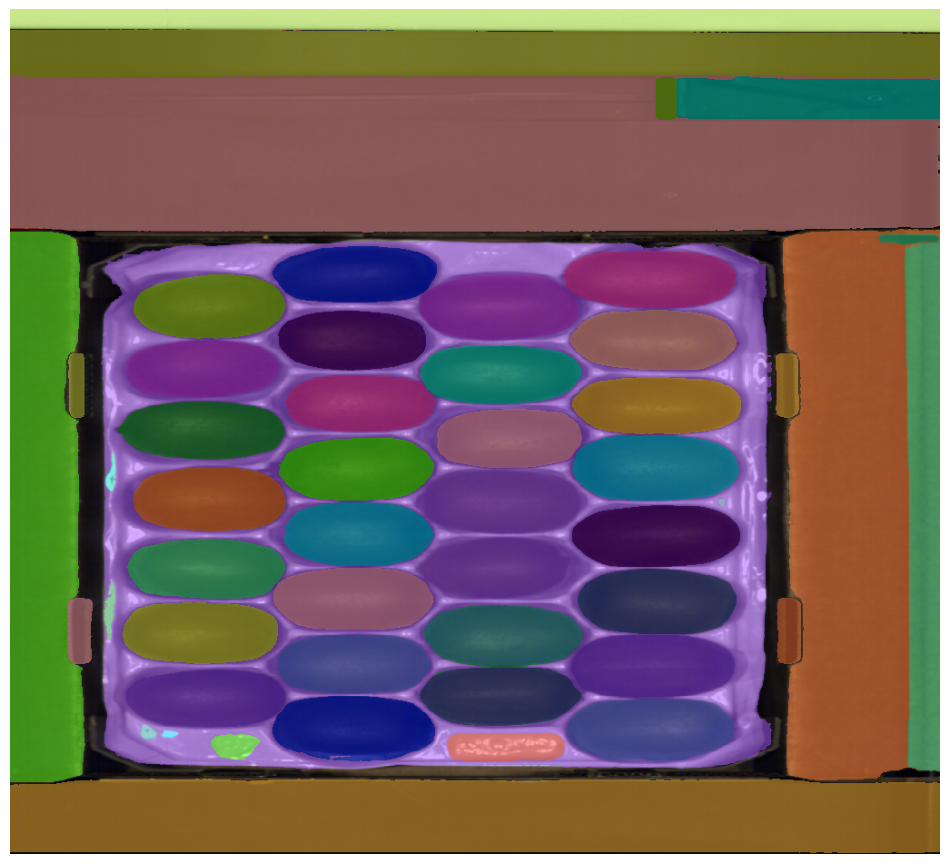

In [8]:
mask_annotator = sv.MaskAnnotator(color_lookup = sv.ColorLookup.INDEX)
sam_result = mask_annotator.annotate(scene=rgb_img.copy(), detections=sam_detections)
sv.plot_image(image=sam_result)

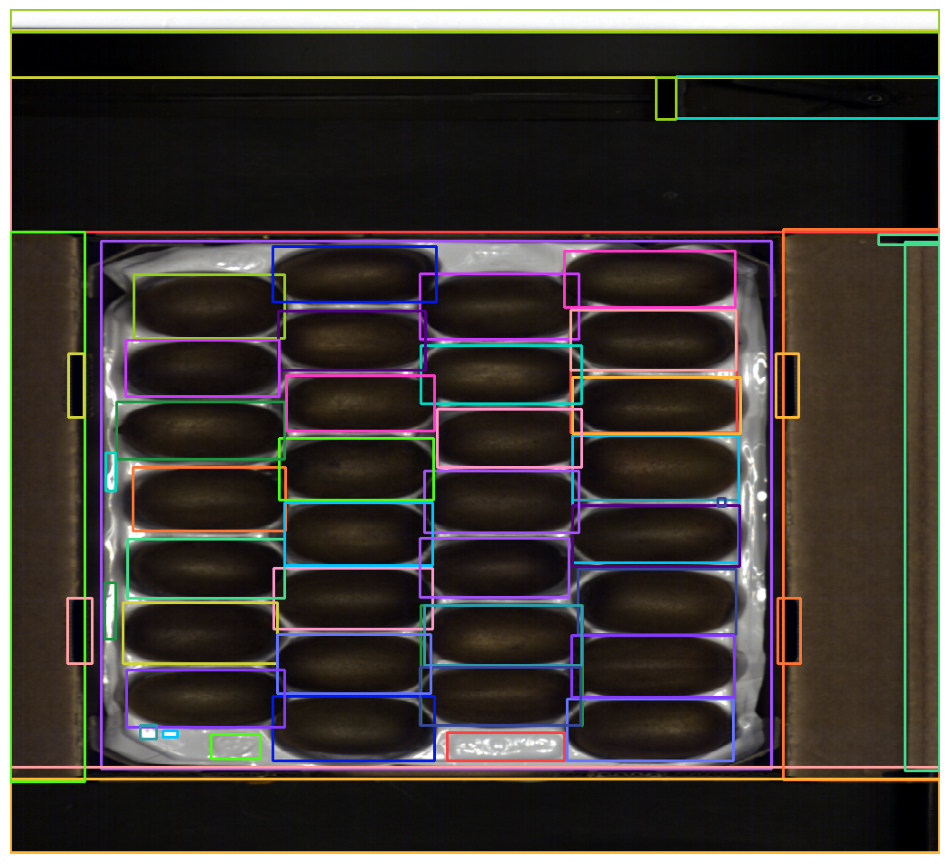

In [10]:
#visulaize with bounding boxes
box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
boxed_image = box_annotator.annotate(scene=rgb_img.copy(), detections=sam_detections)
sv.plot_image(image=boxed_image)


0: 608x640 2 ovens, 6.0ms
Speed: 2.1ms preprocess, 6.0ms inference, 1.6ms postprocess per image at shape (1, 3, 608, 640)


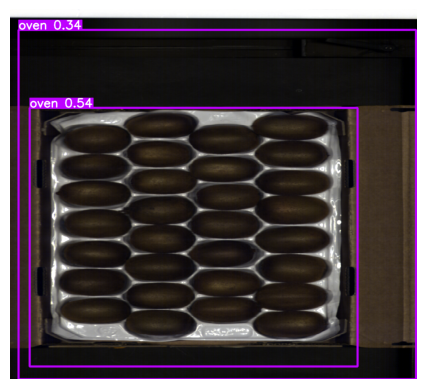

oven: 0.54
oven: 0.34


In [14]:
# use pretrained model to detect objects and visualize with masks and bounding boxes
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load a pretrained YOLOv8 model (you can use 'yolov8n.pt' for speed or 'yolov8m.pt' for accuracy)
model = YOLO('yolov8n.pt')

# Run detection
results = model(rgb_img)

# Get annotated image (numpy array)
annotated_frame = results[0].plot()

# Convert BGR to RGB for matplotlib
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

# Show inline
plt.imshow(annotated_frame)
plt.axis('off')
plt.show()

# Optionally print detections
for box in results[0].boxes:
    cls = int(box.cls[0])
    label = model.names[cls]
    conf = float(box.conf[0])
    print(f"{label}: {conf:.2f}")

That is because pretrained model only was trained on the following labels:
`['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck',
 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench',
 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 
 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 
 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup',
 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
 'toothbrush']`


 What happens if we try on image with the images of for example carrots:


0: 480x640 1 person, 11 carrots, 54.1ms
Speed: 2.9ms preprocess, 54.1ms inference, 5.4ms postprocess per image at shape (1, 3, 480, 640)


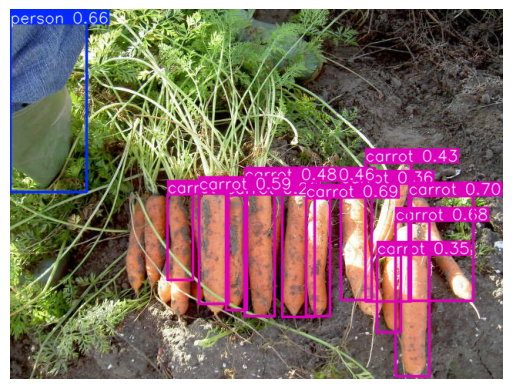

carrot: 0.70
carrot: 0.69
carrot: 0.68
person: 0.66
carrot: 0.59
carrot: 0.48
carrot: 0.46
carrot: 0.43
carrot: 0.36
carrot: 0.35
carrot: 0.26
carrot: 0.25


In [15]:
carrot_img = cv2.imread(f"{data_path}/carrots.jpg")

# Run detection
results = model(carrot_img)

# Get annotated image (numpy array)
annotated_frame = results[0].plot()

# Convert BGR to RGB for matplotlib
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

# Show inline
plt.imshow(annotated_frame)
plt.axis('off')
plt.show()

# Optionally print detections
for box in results[0].boxes:
    cls = int(box.cls[0])
    label = model.names[cls]
    conf = float(box.conf[0])
    print(f"{label}: {conf:.2f}")

## Combining hyperspectral with ResNet


In [21]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os

# 1. Load pretrained ResNet model
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.eval()

# 2. Remove the final classification layer (keep up to penultimate layer)
feature_extractor = nn.Sequential(*list(model.children())[:-1])  # outputs 2048-dim feature

# 3. Define image preprocessing (must match training setup of ResNet)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 4. Function to extract features
def extract_features(img_path):
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)  # shape: [1, 3, 224, 224]
    with torch.no_grad():
        features = feature_extractor(tensor)
    return features.squeeze().numpy()  # shape: (2048,)

# 5. Example for a folder of pork belly images
image_folder = f"{data_path}/pork_belly"
features_dict = {}

for filename in os.listdir(image_folder):
    if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
        path = os.path.join(image_folder, filename)
        features = extract_features(path)
        features_dict[filename] = features

print(f"Extracted {len(features_dict)} feature vectors.")


Extracted 3 feature vectors.


In [23]:
import scipy.io

filepath = f"{data_path}/spatial_spectra_pig.mat"
mat = scipy.io.loadmat(filepath)
print(mat["spatial"].shape)
print(mat["spectral"].shape)
print(mat["ref"].shape)

mat.keys()

(182, 512)
(182, 300)
(182, 1)


dict_keys(['__header__', '__version__', '__globals__', 'ref', 'spatial', 'spectral'])

In [25]:
from helperfunctions.rosa_pls import rosa_pls, PLS, optimise_rosa_pls_cv_test
import kennard_stone as ks
import numpy as np

X_train_spatial, X_test_spatial, y_train, y_test = ks.train_test_split(mat["spatial"], mat["ref"], test_size=0.2, random_state=1)

def get_indices(X_original, X_subset):
    return np.array([np.where(np.all(np.isclose(X_original, x), axis=1))[0][0] for x in X_subset])

train_idx = get_indices(mat["spatial"], X_train_spatial)
test_idx = get_indices(mat["spatial"], X_test_spatial)

X_train_spectral = mat["spectral"][train_idx, :]
X_test_spectral = mat["spectral"][test_idx, :]



2025-10-23 17:11:55,229 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

2025-10-23 17:11:55,237 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.



In [35]:
X_cal_blocks = [X_train_spatial, X_train_spectral]
y_cal = y_train
X_test_blocks = [X_test_spatial, X_test_spectral]
# define component combinations to test
from itertools import product
comp_combinations = list(product(range(1,25), repeat=2))

best_combo = optimise_rosa_pls_cv_test(
    X_cal_blocks, y_cal,
    X_test_blocks, y_test,
    comp_combinations=comp_combinations,
    n_splits=5
)

Best component combination: (4, 11)


In [36]:
results = rosa_pls(X_blocks=X_cal_blocks, Y=y_cal, ncomp_list=best_combo)

Results of normal PLS


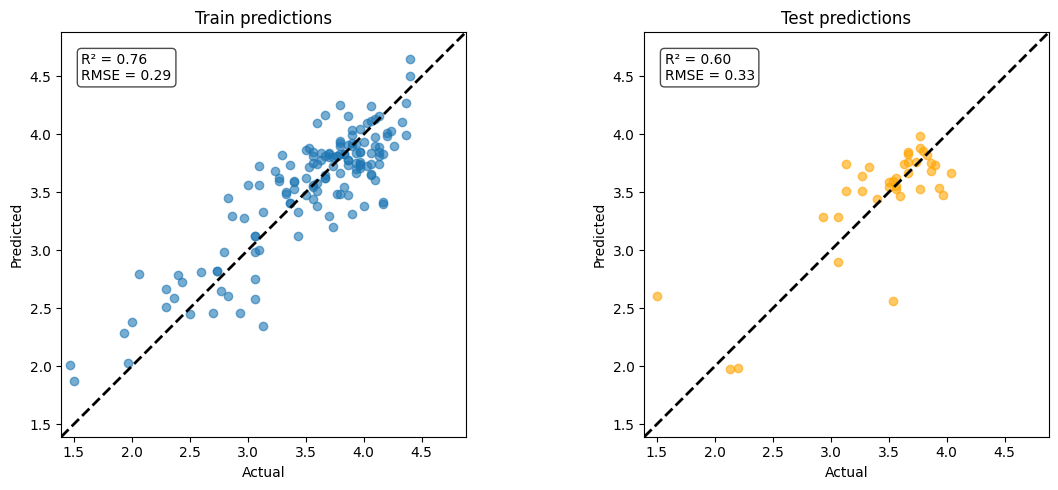

In [38]:
# testing performance without spatial features

from sklearn.cross_decomposition import PLSRegression
from helperfunctions.plot_functions import plot_cv_vs_test

pls = PLSRegression(n_components=11)
pls.fit(X_cal_blocks[1],y_cal)
y_pred_pls_cv = pls.predict(X_cal_blocks[1])
y_pred_pls_test = pls.predict(X_test_blocks[1])
print("Results of normal PLS")
plot_cv_vs_test(y_cal, y_pred_pls_cv, y_test, y_pred_pls_test, plot_titles=["Train predictions", "Test predictions"])

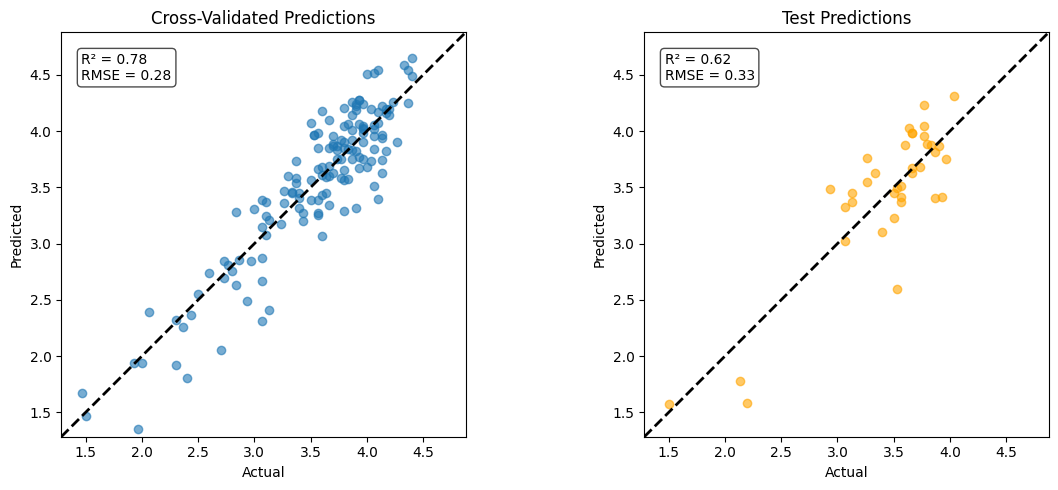

In [37]:
from helperfunctions.plot_functions import plot_cv_vs_test
y_cal_pred = np.sum([
    result['pls'].predict(X_cal_blocks[k], best_combo[k])
    for k, result in enumerate(results)
], axis=0)
y_test_pred = np.sum([
    result['pls'].predict(X_test_blocks[k], best_combo[k])
    for k, result in enumerate(results)
], axis=0)
plot_cv_vs_test(y_cal, y_cal_pred, y_test, y_test_pred)